## Training FP16-INT4

In [1]:
!pip install -q -U boto3 chromadb open_clip_torch bitsandbytes

In [2]:
# Importing useful dependencies
import io
import time
import torch
import boto3
import random
import functools
import numpy as np
from PIL import Image
from io import BytesIO
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import List, Tuple
import torch.nn.functional as F
from open_clip.loss import ClipLoss
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import CLIPProcessor, CLIPModel, BitsAndBytesConfig

# Set a seed for reproducibility
def set_seed(SEED=42):
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)

set_seed(10721)

In this notebook, we fine-tune the pretrained CLIP model **ViT-L/16** using the training data prepared in the previous Zone.

We begin by splitting the dataset into **train**, **development (dev)**, and **test** sets. During fine-tuning, **only the training set** will be used to update the model parameters. After training is complete, the **dev set** will be used for a quick evaluation to verify whether the model generalizes properly. The **test set** will be held out entirely and will not be used until the next Zone.

In [3]:
# Setup S3 client for MinIO (MinIO implements Amazon S3 API)
s3 = boto3.client(
    "s3",
    endpoint_url="http://127.0.0.1:9000", # MinIO API endpoint for local environment
    #endpoint_url="https://tirelessly-unslouching-delaine.ngrok-free.dev", # MinIO API endpoint (ngrok) if you use cloud server you need that
    aws_access_key_id="minioadmin", # User name
    aws_secret_access_key="minioadmin", # Password
)

In [4]:
# Just in case our device has gpu
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load CLIP ViT-L/16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # Load weights in 4-bit
    bnb_4bit_compute_dtype=torch.float32, # Use FP32 for internal compute/accumulation
    bnb_4bit_use_double_quant=True # Optional: improves accuracy
)
model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    quantization_config=bnb_config,
    dtype=torch.float32,
    device_map="cuda"
)
# Load the processor (handles tokenization + image preprocessing)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [5]:
# ---- Show parameter counts ----
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: CLIP-ViT-B-16")
print(f"Total parameters: {total_params:,}") # Before Quantization: 149,620,737
print(f"Trainable parameters: {trainable_params:,}") # Before Quantization: 149,620,737
print(f"The parameters are in: {str(next(model.parameters()).dtype)}") # Before Quantization: FP32

Model: CLIP-ViT-B-16
Total parameters: 88,082,433
Trainable parameters: 26,405,889
The parameters are in: torch.float32


### Dataloader

In [6]:
# Customized Dataloader class for our project
class ImageTextDataset(Dataset):
    def __init__(self, data_bucket, data_prefix, s3):
        self.data_bucket = data_bucket
        self.data_prefix = data_prefix
        self.s3 = s3

        # Data keys
        self.image_keys, self.text_keys = self.__loadfromminio__(data_bucket, data_prefix)

    def __loadfromminio__(self, data_bucket, data_prefix):
        image_keys = []
        text_keys = []
        paginator = self.s3.get_paginator("list_objects_v2")
        for page in paginator.paginate(Bucket=data_bucket, Prefix=data_prefix):
            for obj in page.get("Contents", []):
                  key = obj["Key"]
                  if obj['Size'] == 0 and key.endswith("/"):
                      continue
                  if "image" in key.split("/")[1]: # We only need images to find their corresponding description in MinIO
                      image_keys.append(key)
                      text_key = data_prefix + key.split("/")[1].replace("image", "text").replace("png", "txt")
                      text_keys.append(text_key)

        # From lists to arrays
        image_keys = np.array(image_keys)
        text_keys = np.array(text_keys)

        return image_keys, text_keys

    def __len__(self):
        return len(self.image_keys)

    def __getfile__(self, data_bucket, key, filetype = "image"):
        resp = self.s3.get_object(Bucket=data_bucket, Key=key)
        body = resp["Body"].read()
        if filetype == "image":
            file = Image.open(BytesIO(body))
        else: # filetype = "text"
            file = body.decode("utf-8")
        return file

    def __getitem__(self, idx):

        # Load image
        image = self.__getfile__(self.data_bucket, self.image_keys[idx], filetype = "image")

        # Load text
        text = self.__getfile__(self.data_bucket, self.text_keys[idx], filetype = "text")

        return image, text

# Collate function that applies preprocess and tokenizer to the batch
def collate_fn(batch: List[Tuple[Image.Image, str]], processor: CLIPProcessor):
    """
    batch: list of (PIL.Image, text_str)
    processor: Hugging Face CLIPProcessor
    Returns:
        images: torch.Tensor [B, C, H, W]
        input_ids: torch.LongTensor [B, L]
        attention_mask: torch.LongTensor [B, L]
        raw_texts: list[str]
    """
    images_pil, raw_texts = zip(*batch)

    # Use processor to handle both images and text
    processed = processor(
        text=list(raw_texts),
        images=list(images_pil),
        return_tensors="pt",
        padding=True,
        truncation=True,   # ensure sequences do not exceed max length
        max_length=77      # CLIP default
    )

    return (
        processed['pixel_values'],   # tensor [B, C, H, W]
        processed['input_ids'],      # tensor [B, L]
        processed['attention_mask'], # tensor [B, L]
        list(raw_texts)              # original texts
    )

# Wrap for DataLoader
collate = functools.partial(collate_fn, processor=processor)

Next, we create a Dataloader object for each of the training data.

In [7]:
# Create customized dataset objects
baseline_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "baseline-training-data/",
    s3 = s3
)
augmented_1_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "text_augmented-training-data/",
    s3 = s3
)
augmented_2_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "image_augmented-training-data/",
    s3 = s3
)
augmented_3_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "text_image_augmented-training-data/",
    s3 = s3
)

The data split is performed in the next cell. First, **80% of the full dataset** is allocated for training, while the remaining **20% is reserved for testing**. Then, the training portion is further divided: **80% is used for actual training**, and the remaining **20% is used as the development set**.

In [8]:
# Given the size of a dataset, the function returns the splits
def get_set_sizes(dataset_size):
  train_size = int(0.64 * dataset_size) # 0.8 * 0.8 = 0.64
  dev_size = int(0.16 * dataset_size) # 0.8 * 0.2 = 0.16
  test_size = dataset_size - train_size - dev_size # 0.2
  return [train_size, dev_size, test_size]

set_seed(10721)
# Split the training data into train/dev/test sets, the test sets won't be used in this notebook
base_train_dataset, base_dev_dataset, _ = random_split(baseline_dataset, get_set_sizes(len(baseline_dataset)))
aug1_train_dataset, aug1_dev_dataset, _ = random_split(augmented_1_dataset, get_set_sizes(len(augmented_1_dataset)))
aug2_train_dataset, aug2_dev_dataset, _ = random_split(augmented_2_dataset, get_set_sizes(len(augmented_2_dataset)))
aug3_train_dataset, aug3_dev_dataset, _ = random_split(augmented_3_dataset, get_set_sizes(len(augmented_3_dataset)))

In [9]:
set_seed(10721)
# Apply a shuffle over the dataset to prevent the model from learning order-based patterns
dataloader0 = DataLoader(base_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader1 = DataLoader(aug1_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader2 = DataLoader(aug2_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader3 = DataLoader(aug3_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
# Increasing the size of the batch slows down the training process, but generalizes better the model

In [10]:
# Create a model for all cases
model_0 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    quantization_config=bnb_config,
    dtype=torch.float32,
    device_map="cuda"
)
model_1 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    quantization_config=bnb_config,
    dtype=torch.float32,
    device_map="cuda"
)
model_2 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    quantization_config=bnb_config,
    dtype=torch.float32,
    device_map="cuda"
)
model_3 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    quantization_config=bnb_config,
    dtype=torch.float32,
    device_map="cuda"
)

### Fine-tuning

In [11]:
# The function trains the model given the model and the dataloader
def fine_tune(model, dataloader, epochs=1):

  criterion = ClipLoss()

  # Test fine-tuning on ViT-B-16 with Mixed/Reduced Precision (FP16)

  losses = [] # Store losses
  latencies = [] # ms per iteration
  throughputs = [] # samples per second
  gpu_mem_usage = [] # GB

  # AdamW optimizer
  optimizer = optim.AdamW(model.parameters(), lr=1e-6)
  # Big lr leads to overfitting on the training data ->
  # the model will get better results on the training data, but poor results on the test set

  # Initialize GradScaler
  scaler = torch.amp.GradScaler('cuda')

  for epoch in range(1, epochs + 1):

    print(f"\n===== Epoch {epoch} / {epochs} =====")

    for images, input_ids, attention_mask, raw_texts in dataloader:
      # Move to device
      images = images.to(device)
      input_ids = input_ids.to(device)
      attention_mask = attention_mask.to(device)

      batch_size = images.size(0)
      torch.cuda.reset_peak_memory_stats(device)
      start_time = time.perf_counter()
      optimizer.zero_grad()

      # Clamp logit scale to avoid overflow
      with torch.no_grad():
          model.logit_scale.data = model.logit_scale.data.clamp(max=1.5)

      # Forward in FP16 using autocast
      with torch.amp.autocast('cuda'):
          img_feats = model.get_image_features(images)
          txt_feats = model.get_text_features(
              input_ids=input_ids,
              attention_mask=attention_mask
          )
          loss = criterion(img_feats, txt_feats, model.logit_scale.exp())

      # Backward with gradient scaling
      scaler.scale(loss).backward()
      scaler.unscale_(optimizer)  # unscale before gradient clipping
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      scaler.step(optimizer)
      scaler.update()

      torch.cuda.synchronize(device)
      end_time = time.perf_counter()

      # Metrics
      latency_ms = (end_time - start_time) * 1000
      throughput = batch_size / (end_time - start_time)
      peak_mem_gb = torch.cuda.max_memory_allocated(device) / 1e9

      # Append metrics
      losses.append(loss.item())
      latencies.append(latency_ms)
      throughputs.append(throughput)
      gpu_mem_usage.append(peak_mem_gb)

      print(
          f"Loss: {loss.item():.4f} | "
          f"Latency: {latency_ms:.2f} ms | "
          f"Throughput: {throughput:.2f} samples/s | "
          f"GPU Mem: {peak_mem_gb:.2f} GB"
      )

  # ----- Plot metrics -----
  fig, axes = plt.subplots(2, 2, figsize=(14,10))

  axes[0, 0].plot(losses, marker='o')
  axes[0, 0].set_title("Training Loss")
  axes[0, 0].set_xlabel("Iteration")
  axes[0, 0].set_ylabel("Loss")
  axes[0, 0].grid(True)

  axes[0, 1].plot(latencies, marker='o')
  axes[0, 1].set_title("Latency per Iteration (ms)")
  axes[0, 1].set_xlabel("Iteration")
  axes[0, 1].set_ylabel("Latency (ms)")
  axes[0, 1].grid(True)

  axes[1, 0].plot(throughputs, marker='o')
  axes[1, 0].set_title("Throughput (samples/s)")
  axes[1, 0].set_xlabel("Iteration")
  axes[1, 0].set_ylabel("Samples / second")
  axes[1, 0].grid(True)

  axes[1, 1].plot(gpu_mem_usage, marker='o')
  axes[1, 1].set_title("Peak GPU Memory Usage (GB)")
  axes[1, 1].set_xlabel("Iteration")
  axes[1, 1].set_ylabel("Memory (GB)")
  axes[1, 1].grid(True)

  plt.tight_layout()
  plt.show()

  return losses, latencies, throughputs, gpu_mem_usage

In [12]:
def store_model_weights_on_MinIO(s3, model, bucket, file_name):
  buffer = io.BytesIO()
  # Save state_dict into memory buffer
  torch.save(model_0.state_dict(), buffer)
  # Reset buffer pointer
  buffer.seek(0)
  # Upload to MinIO
  s3.upload_fileobj(
      buffer,
      Bucket=bucket,
      Key=file_name
  )

**Fine-tuning Using Baseline Training Data**


===== Epoch 1 / 10 =====
Loss: 4.6354 | Latency: 1184.66 ms | Throughput: 6.75 samples/s | GPU Mem: 1.80 GB
Loss: 3.2112 | Latency: 313.75 ms | Throughput: 25.50 samples/s | GPU Mem: 1.80 GB
Loss: 2.9019 | Latency: 165.34 ms | Throughput: 48.38 samples/s | GPU Mem: 1.80 GB
Loss: 0.0011 | Latency: 244.94 ms | Throughput: 32.66 samples/s | GPU Mem: 1.80 GB
Loss: 1.1799 | Latency: 159.20 ms | Throughput: 50.25 samples/s | GPU Mem: 2.01 GB
Loss: 2.0056 | Latency: 129.67 ms | Throughput: 61.70 samples/s | GPU Mem: 2.01 GB
Loss: 0.5008 | Latency: 150.07 ms | Throughput: 53.31 samples/s | GPU Mem: 2.01 GB
Loss: 0.0906 | Latency: 161.81 ms | Throughput: 49.44 samples/s | GPU Mem: 2.01 GB
Loss: 0.6680 | Latency: 172.25 ms | Throughput: 46.44 samples/s | GPU Mem: 2.01 GB
Loss: 0.0009 | Latency: 148.15 ms | Throughput: 54.00 samples/s | GPU Mem: 2.01 GB
Loss: 1.4829 | Latency: 156.37 ms | Throughput: 51.16 samples/s | GPU Mem: 2.01 GB
Loss: 4.3265 | Latency: 171.35 ms | Throughput: 46.69 samples

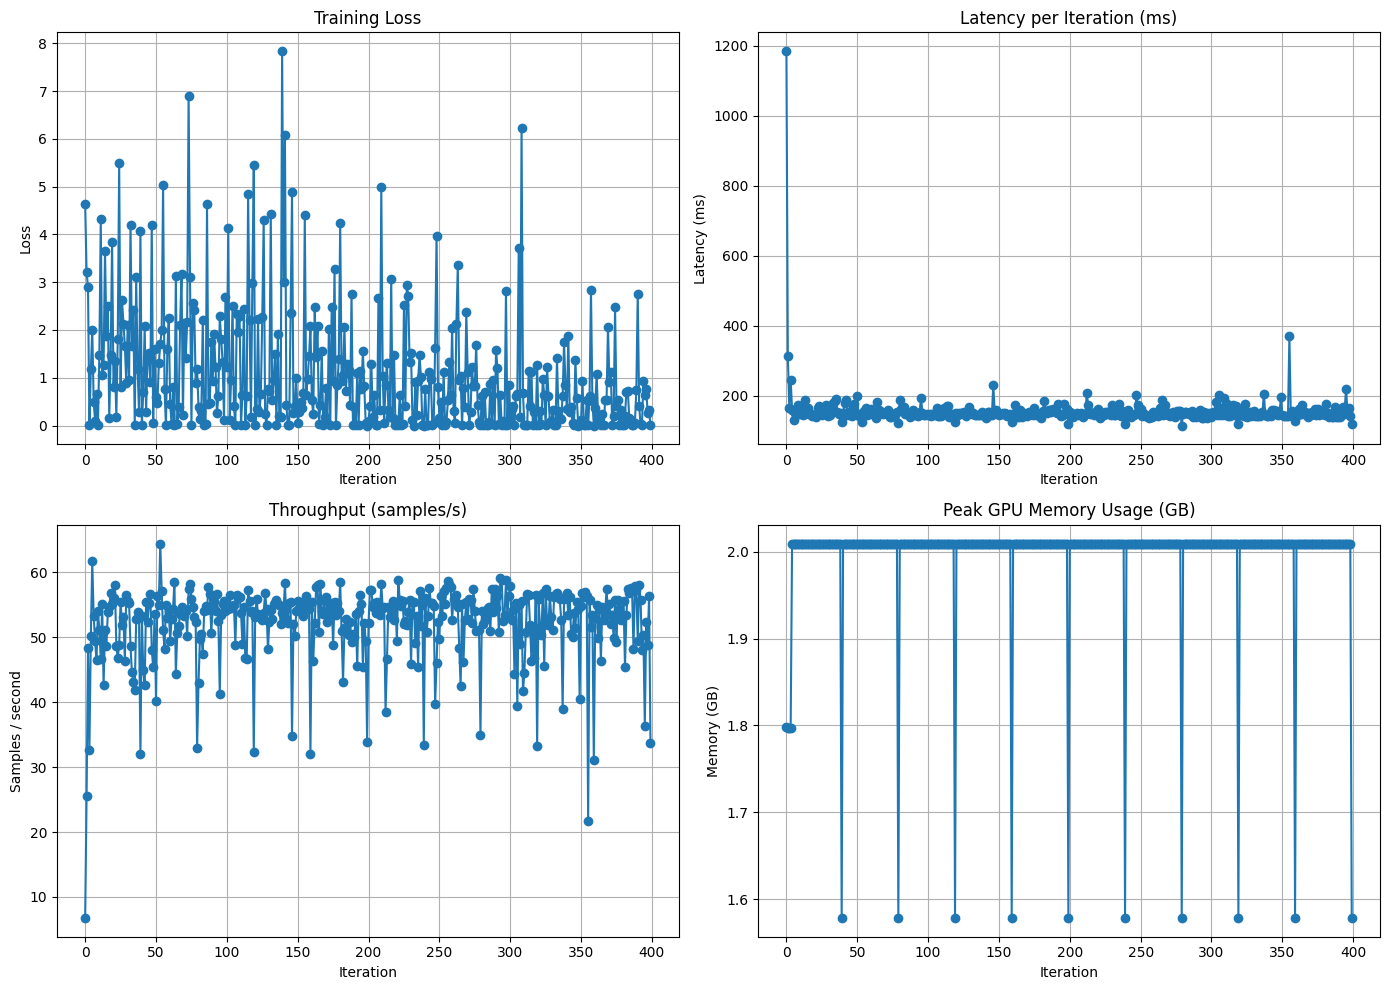

In [13]:
set_seed(10721)
# Fine-tuning the first model
losses_0, latencies_0, throughputs_0, gpu_mem_usage_0 = fine_tune(model_0, dataloader0, epochs=10)
#store_model_weights_on_MinIO(s3, model_0, "training-zone", "FP16-INT4/fine-tuned_FP16-INT4_0.pt")

**Fine-tuning Using Text-augmented Training Data**


===== Epoch 1 / 10 =====
Loss: 1.7433 | Latency: 137.36 ms | Throughput: 58.24 samples/s | GPU Mem: 1.90 GB
Loss: 0.6357 | Latency: 130.23 ms | Throughput: 61.43 samples/s | GPU Mem: 1.90 GB
Loss: 0.9820 | Latency: 136.50 ms | Throughput: 58.61 samples/s | GPU Mem: 1.90 GB
Loss: 0.0003 | Latency: 177.27 ms | Throughput: 45.13 samples/s | GPU Mem: 1.90 GB
Loss: 0.2950 | Latency: 124.59 ms | Throughput: 64.21 samples/s | GPU Mem: 2.11 GB
Loss: 0.6627 | Latency: 179.10 ms | Throughput: 44.67 samples/s | GPU Mem: 2.11 GB
Loss: 0.4958 | Latency: 158.56 ms | Throughput: 50.45 samples/s | GPU Mem: 2.11 GB
Loss: 5.0225 | Latency: 134.77 ms | Throughput: 59.36 samples/s | GPU Mem: 2.11 GB
Loss: 0.0005 | Latency: 146.44 ms | Throughput: 54.63 samples/s | GPU Mem: 2.11 GB
Loss: 1.6315 | Latency: 166.41 ms | Throughput: 48.07 samples/s | GPU Mem: 2.11 GB
Loss: 2.9581 | Latency: 150.61 ms | Throughput: 53.12 samples/s | GPU Mem: 2.11 GB
Loss: 0.2884 | Latency: 198.11 ms | Throughput: 40.38 samples

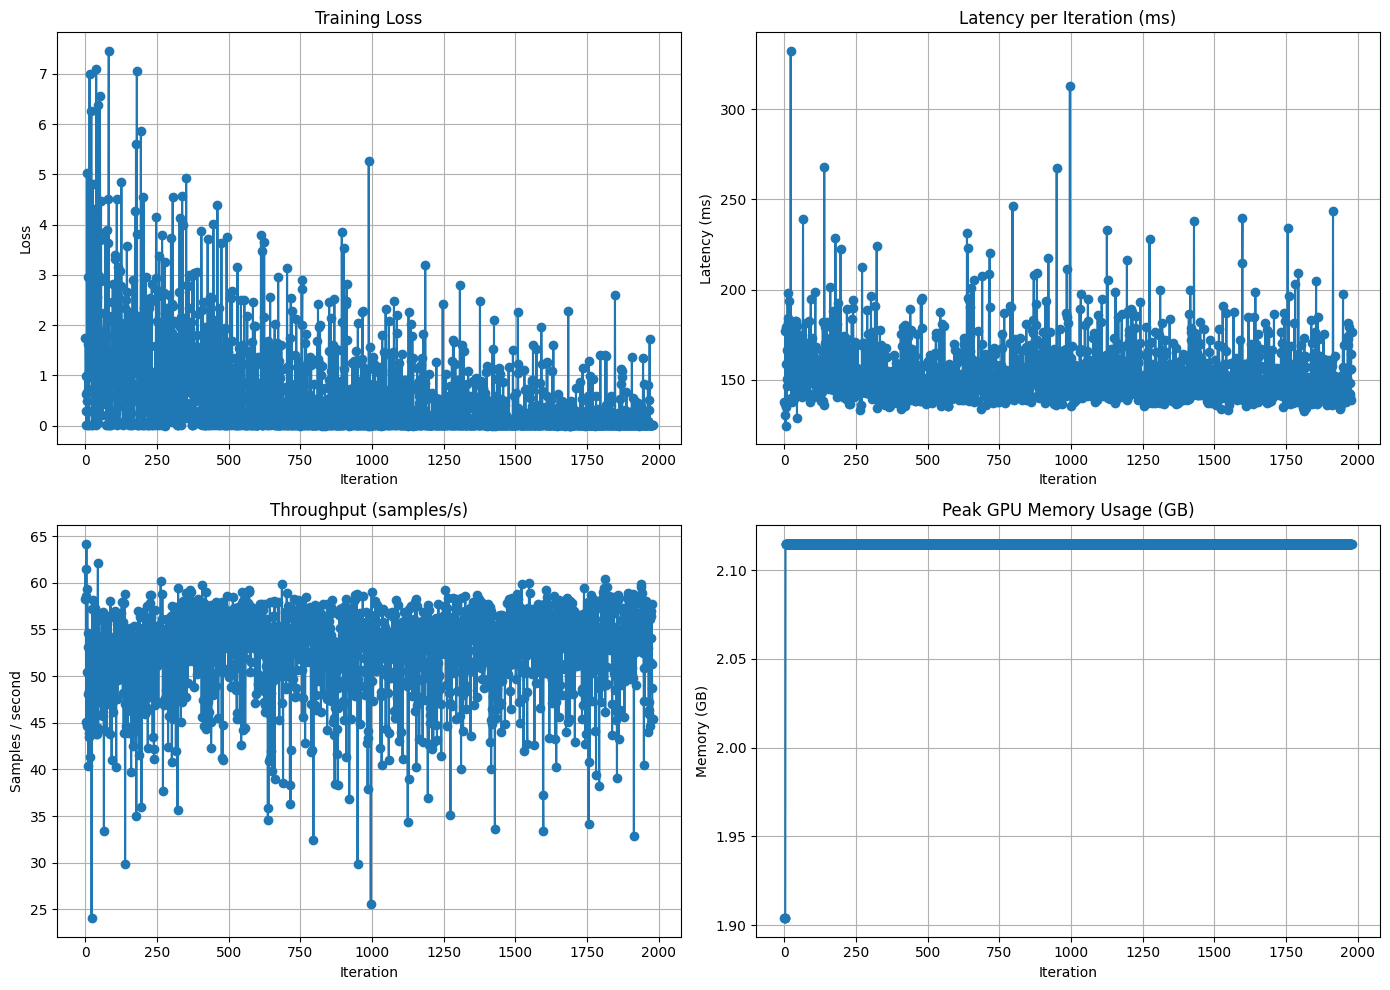

In [14]:
set_seed(10721)
# Fine-tuning the second model
losses_1, latencies_1, throughputs_1, gpu_mem_usage_1 = fine_tune(model_1, dataloader1, epochs=10)
#store_model_weights_on_MinIO(s3, model_1, "training-zone", "FP16-INT4/fine-tuned_FP16-INT4_1.pt")

**Fine-tuning Using Image-augmented Training Data**


===== Epoch 1 / 10 =====
Loss: 0.9084 | Latency: 135.33 ms | Throughput: 59.11 samples/s | GPU Mem: 2.01 GB
Loss: 0.0003 | Latency: 145.98 ms | Throughput: 54.80 samples/s | GPU Mem: 2.01 GB
Loss: 0.2211 | Latency: 195.95 ms | Throughput: 40.83 samples/s | GPU Mem: 2.22 GB
Loss: 2.0758 | Latency: 133.43 ms | Throughput: 59.96 samples/s | GPU Mem: 2.22 GB
Loss: 4.2741 | Latency: 168.30 ms | Throughput: 47.54 samples/s | GPU Mem: 2.22 GB
Loss: 1.4076 | Latency: 129.07 ms | Throughput: 61.98 samples/s | GPU Mem: 2.22 GB
Loss: 1.6232 | Latency: 137.78 ms | Throughput: 58.06 samples/s | GPU Mem: 2.22 GB
Loss: 0.5025 | Latency: 146.37 ms | Throughput: 54.66 samples/s | GPU Mem: 2.22 GB
Loss: 1.6788 | Latency: 202.61 ms | Throughput: 39.48 samples/s | GPU Mem: 2.22 GB
Loss: 3.6469 | Latency: 163.01 ms | Throughput: 49.08 samples/s | GPU Mem: 2.22 GB
Loss: 3.2604 | Latency: 149.66 ms | Throughput: 53.45 samples/s | GPU Mem: 2.22 GB
Loss: 1.0141 | Latency: 145.91 ms | Throughput: 54.83 samples

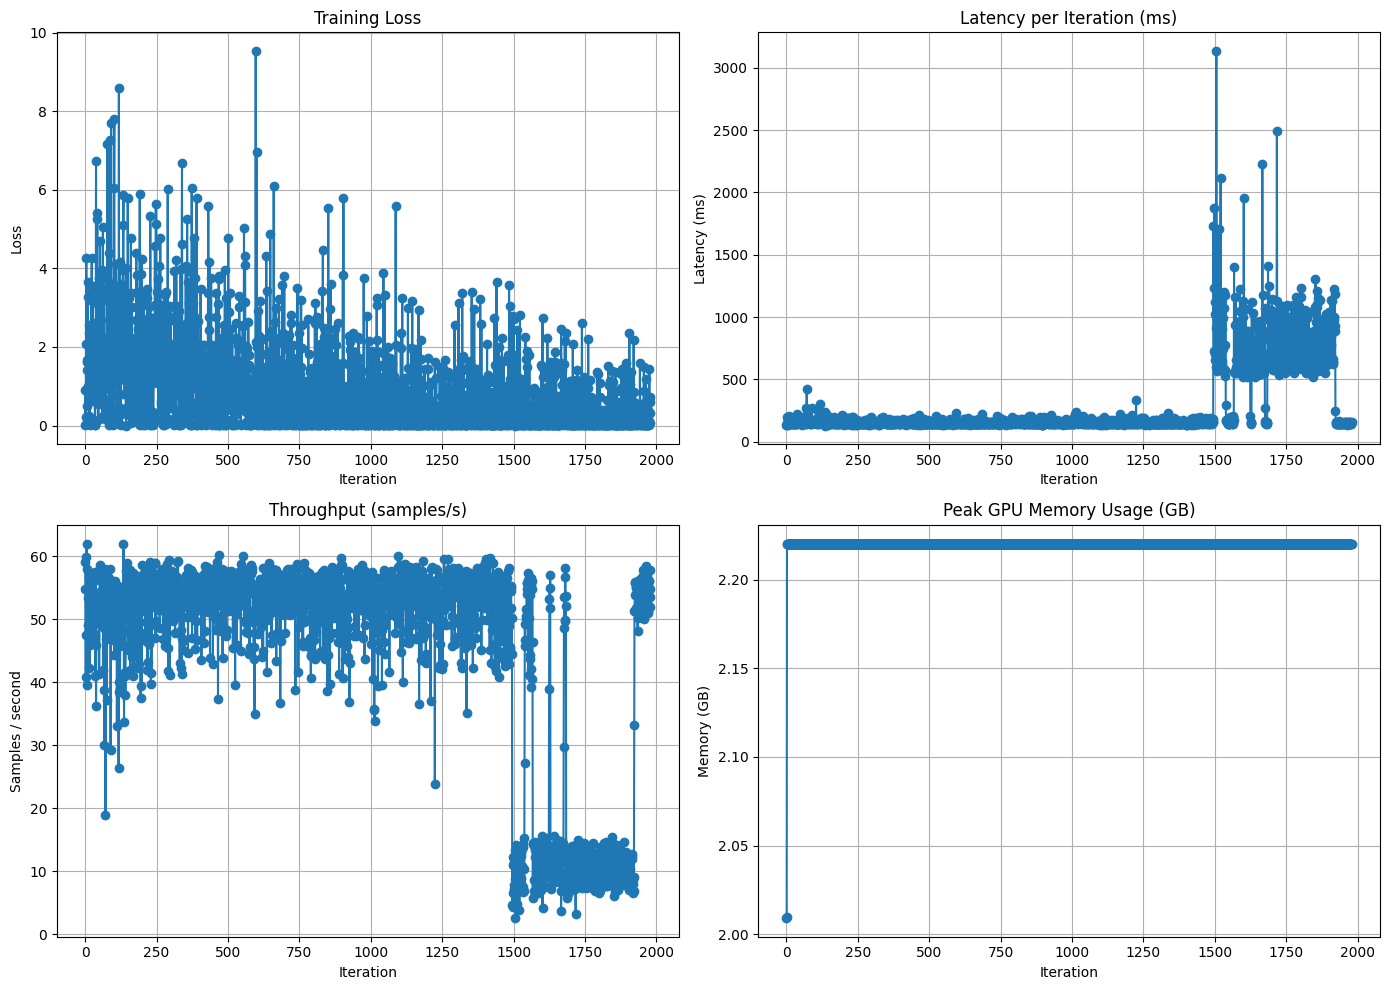

In [15]:
set_seed(10721)
# Fine-tuning the third model
losses_2, latencies_2, throughputs_2, gpu_mem_usage_2 = fine_tune(model_2, dataloader2, epochs=10)
#store_model_weights_on_MinIO(s3, model_2, "training-zone", "FP16-INT4/fine-tuned_FP16-INT4_2.pt")

**Fine-tuning Using Text&Image-augmented Training Data**


===== Epoch 1 / 10 =====
Loss: 4.6375 | Latency: 130.59 ms | Throughput: 61.26 samples/s | GPU Mem: 2.12 GB
Loss: 3.0059 | Latency: 152.11 ms | Throughput: 52.59 samples/s | GPU Mem: 2.12 GB
Loss: 0.8583 | Latency: 140.61 ms | Throughput: 56.90 samples/s | GPU Mem: 2.12 GB
Loss: 2.8992 | Latency: 224.97 ms | Throughput: 35.56 samples/s | GPU Mem: 2.12 GB
Loss: 1.9066 | Latency: 144.49 ms | Throughput: 55.37 samples/s | GPU Mem: 2.12 GB
Loss: 3.2218 | Latency: 140.12 ms | Throughput: 57.09 samples/s | GPU Mem: 2.12 GB
Loss: 1.5058 | Latency: 176.44 ms | Throughput: 45.34 samples/s | GPU Mem: 2.12 GB
Loss: 3.5941 | Latency: 150.07 ms | Throughput: 53.31 samples/s | GPU Mem: 2.33 GB
Loss: 2.2313 | Latency: 142.84 ms | Throughput: 56.01 samples/s | GPU Mem: 2.33 GB
Loss: 0.6754 | Latency: 153.95 ms | Throughput: 51.97 samples/s | GPU Mem: 2.33 GB
Loss: 0.7835 | Latency: 148.65 ms | Throughput: 53.82 samples/s | GPU Mem: 2.33 GB
Loss: 3.7951 | Latency: 143.73 ms | Throughput: 55.66 samples

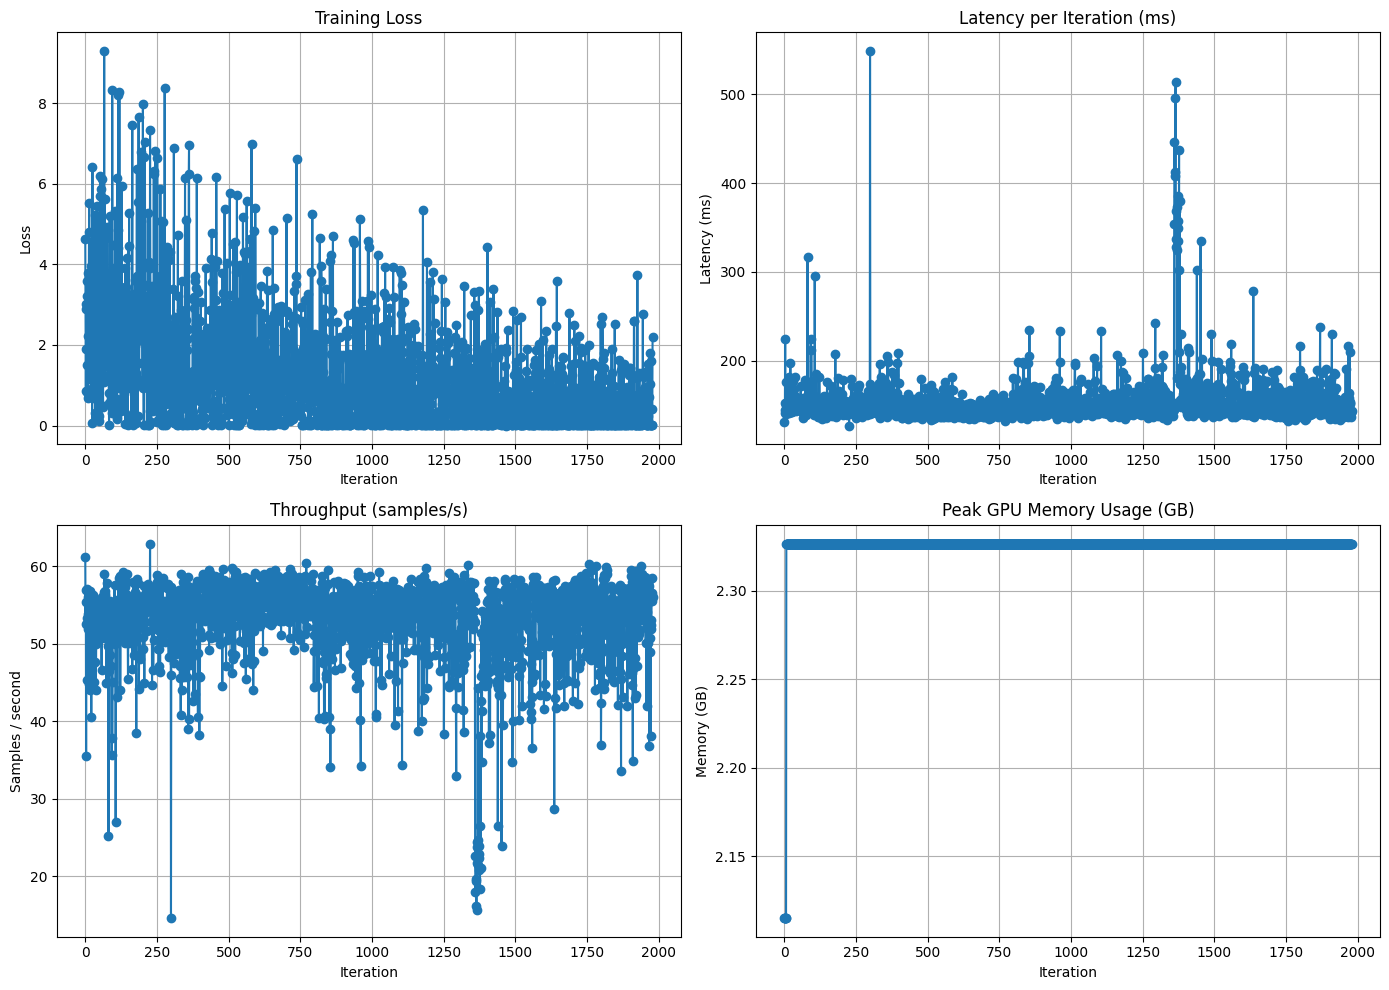

In [16]:

set_seed(10721)
# Fine-tuning the fourth model
losses_3, latencies_3, throughputs_3, gpu_mem_usage_3 = fine_tune(model_3, dataloader3, epochs=10)
#store_model_weights_on_MinIO(s3, model_3, "training-zone", "FP16-INT4/fine-tuned_FP16-INT4_3.pt")

In [17]:
# We can also save the weights to the local and upload them mannually to MinIO
# This is done because of the limited bandwidth of ngrok
torch.save(model_0.state_dict(), "../models/fine-tuned_FP16-INT4_v3_0.pt")
torch.save(model_1.state_dict(), "../models/fine-tuned_FP16-INT4_v3_1.pt")
torch.save(model_2.state_dict(), "../models/fine-tuned_FP16-INT4_v3_2.pt")
torch.save(model_3.state_dict(), "../models/fine-tuned_FP16-INT4_v3_3.pt")

### Evaluation On The Dev Sets

First, we create **DataLoader objects** for the development (dev) sets. These loaders are then used to **evaluate the trained models**, allowing us to assess their performance on unseen data and verify how well they generalize beyond the training set.

In [18]:
set_seed(10721)
# Dev DataLoader objects
dataloader0_dev = DataLoader(base_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader1_dev = DataLoader(aug1_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader2_dev = DataLoader(aug2_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader3_dev = DataLoader(aug3_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)

**Performance Cost**

During training, we recorded **latency (ms)**, **throughput (samples/s)**, and **GPU memory usage (GB)** for each model. In this step, we compute the **mean** and **median** of these metrics to summarize the overall training performance and compare the models in a more stable and interpretable way.


In [19]:
# Given a list, return the mean and the median of the list of values
def get_mean_median_of_list(values):
    return float(np.mean(values)), float(np.median(values))

# Model 0
loss_mean0, loss_median0 = get_mean_median_of_list(losses_0)
latencies_mean0, latencies_median0 = get_mean_median_of_list(latencies_0)
throughputs_mean0, throughputs_median0 = get_mean_median_of_list(throughputs_0)
gpu_mem_usage_mean0, gpu_mem_usage_median0 = get_mean_median_of_list(gpu_mem_usage_0)

# Model 1
loss_mean1, loss_median1 = get_mean_median_of_list(losses_1)
latencies_mean1, latencies_median1 = get_mean_median_of_list(latencies_1)
throughputs_mean1, throughputs_median1 = get_mean_median_of_list(throughputs_1)
gpu_mem_usage_mean1, gpu_mem_usage_median1 = get_mean_median_of_list(gpu_mem_usage_1)

# Model 2
loss_mean2, loss_median2 = get_mean_median_of_list(losses_2)
latencies_mean2, latencies_median2 = get_mean_median_of_list(latencies_2)
throughputs_mean2, throughputs_median2 = get_mean_median_of_list(throughputs_2)
gpu_mem_usage_mean2, gpu_mem_usage_median2 = get_mean_median_of_list(gpu_mem_usage_2)

# Model 3
loss_mean3, loss_median3 = get_mean_median_of_list(losses_3)
latencies_mean3, latencies_median3 = get_mean_median_of_list(latencies_3)
throughputs_mean3, throughputs_median3 = get_mean_median_of_list(throughputs_3)
gpu_mem_usage_mean3, gpu_mem_usage_median3 = get_mean_median_of_list(gpu_mem_usage_3)

In [20]:
print("===== Model 0 =====")
print(f"Loss        | Mean: {loss_mean0:.4f} | Median: {loss_median0:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean0:.2f} | Median: {latencies_median0:.2f}")
print(f"Throughput  | Mean: {throughputs_mean0:.2f} | Median: {throughputs_median0:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean0:.2f} | Median: {gpu_mem_usage_median0:.2f}\n")

print("===== Model 1 =====")
print(f"Loss        | Mean: {loss_mean1:.4f} | Median: {loss_median1:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean1:.2f} | Median: {latencies_median1:.2f}")
print(f"Throughput  | Mean: {throughputs_mean1:.2f} | Median: {throughputs_median1:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean1:.2f} | Median: {gpu_mem_usage_median1:.2f}\n")

print("===== Model 2 =====")
print(f"Loss        | Mean: {loss_mean2:.4f} | Median: {loss_median2:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean2:.2f} | Median: {latencies_median2:.2f}")
print(f"Throughput  | Mean: {throughputs_mean2:.2f} | Median: {throughputs_median2:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean2:.2f} | Median: {gpu_mem_usage_median2:.2f}\n")

print("===== Model 3 =====")
print(f"Loss        | Mean: {loss_mean3:.4f} | Median: {loss_median3:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean3:.2f} | Median: {latencies_median3:.2f}")
print(f"Throughput  | Mean: {throughputs_mean3:.2f} | Median: {throughputs_median3:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean3:.2f} | Median: {gpu_mem_usage_median3:.2f}")

===== Model 0 =====
Loss        | Mean: 1.0812 | Median: 0.6378
Latency (ms)| Mean: 155.19 | Median: 148.12
Throughput  | Mean: 52.13 | Median: 53.78
GPU Mem (GB)| Mean: 2.00 | Median: 2.01

===== Model 1 =====
Loss        | Mean: 0.6036 | Median: 0.1955
Latency (ms)| Mean: 153.19 | Median: 148.89
Throughput  | Mean: 52.69 | Median: 53.73
GPU Mem (GB)| Mean: 2.11 | Median: 2.11

===== Model 2 =====
Loss        | Mean: 0.9650 | Median: 0.5052
Latency (ms)| Mean: 281.73 | Median: 151.44
Throughput  | Mean: 44.55 | Median: 52.83
GPU Mem (GB)| Mean: 2.22 | Median: 2.22

===== Model 3 =====
Loss        | Mean: 1.2517 | Median: 0.8058
Latency (ms)| Mean: 153.80 | Median: 147.28
Throughput  | Mean: 52.97 | Median: 54.32
GPU Mem (GB)| Mean: 2.33 | Median: 2.33


Model 0 has the lowest average loss (median), likely because it was trained on a smaller dataset, so it converges faster. Models 1–3 use datasets roughly five times larger due to data augmentation, increasing complexity and making it harder for the models to learn, which explains their higher losses. Among them, model 1 performs slightly better than models 2 and 3, suggesting that text-augmented data is easier to learn than image-augmented data.

For the hardware metrics: latency and throughput differences are mainly due to environment variability (GPU availability, background processes, or data transfer delays), not model complexity. GPU memory usage is also affected by the order of execution: the first model to train typically uses less memory, while subsequent models show higher usage due to memory fragmentation and residual allocations, though it remains within Colab limits.



**Alignment**

In [21]:
# Collect embeddings
@torch.no_grad()
def collect_embeddings(model, dataloader, device):
    model.eval()

    all_image_feats = []
    all_text_feats = []

    for images, input_ids, attention_mask, _ in dataloader:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        img_feats = model.get_image_features(images)
        txt_feats = model.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Normalize (CRITICAL for cosine similarity)
        img_feats = F.normalize(img_feats, dim=-1)
        txt_feats = F.normalize(txt_feats, dim=-1)

        all_image_feats.append(img_feats)
        all_text_feats.append(txt_feats)

    all_image_feats = torch.cat(all_image_feats, dim=0)
    all_text_feats = torch.cat(all_text_feats, dim=0)

    return all_image_feats, all_text_feats

# Compute similarity matrix
def compute_similarity(image_feats, text_feats):
    # cosine similarity via dot product (since normalized)
    return text_feats @ image_feats.T

# Compute Recall@K and MRR
def retrieval_metrics(similarity, ks=(1, 5)):
    num_queries = similarity.size(0)

    # Ground truth: text i ↔ image i
    gt = torch.arange(num_queries, device=similarity.device)

    # Sort images by similarity (descending)
    rankings = torch.argsort(similarity, dim=1, descending=True)

    recalls = {k: 0 for k in ks}
    mrr = 0.0

    for i in range(num_queries):
        rank = (rankings[i] == gt[i]).nonzero(as_tuple=True)[0].item() + 1

        for k in ks:
            if rank <= k:
                recalls[k] += 1

        mrr += 1.0 / rank

    for k in ks:
        recalls[k] /= num_queries

    mrr /= num_queries

    return recalls, mrr

In [22]:
# Baseline model vs model 0
image_feats_base_0, text_feats_base_0 = collect_embeddings(model, dataloader0_dev, device)
similarity_base_0 = compute_similarity(image_feats_base_0, text_feats_base_0)
recalls_base_0, mrr_base_0 = retrieval_metrics(similarity_base_0, ks=(1, 5))

image_feats_0, text_feats_0 = collect_embeddings(model_0, dataloader0_dev, device)
similarity_0 = compute_similarity(image_feats_0, text_feats_0)
recalls_0, mrr_0 = retrieval_metrics(similarity_0, ks=(1, 5))

# Baseline model vs model 1
image_feats_base_1, text_feats_base_1 = collect_embeddings(model, dataloader1_dev, device)
similarity_base_1 = compute_similarity(image_feats_base_1, text_feats_base_1)
recalls_base_1, mrr_base_1 = retrieval_metrics(similarity_base_1, ks=(1, 5))

image_feats_1, text_feats_1 = collect_embeddings(model_1, dataloader1_dev, device)
similarity_1 = compute_similarity(image_feats_1, text_feats_1)
recalls_1, mrr_1 = retrieval_metrics(similarity_1, ks=(1, 5))

# Baseline model vs model 2
image_feats_base_2, text_feats_base_2 = collect_embeddings(model, dataloader2_dev, device)
similarity_base_2 = compute_similarity(image_feats_base_2, text_feats_base_2)
recalls_base_2, mrr_base_2 = retrieval_metrics(similarity_base_2, ks=(1, 5))

image_feats_2, text_feats_2 = collect_embeddings(model_2, dataloader2_dev, device)
similarity_2 = compute_similarity(image_feats_2, text_feats_2)
recalls_2, mrr_2 = retrieval_metrics(similarity_2, ks=(1, 5))

# Baseline model vs model 3
image_feats_base_3, text_feats_base_3 = collect_embeddings(model, dataloader3_dev, device)
similarity_base_3 = compute_similarity(image_feats_base_3, text_feats_base_3)
recalls_base_3, mrr_base_3 = retrieval_metrics(similarity_base_3, ks=(1, 5))

image_feats_3, text_feats_3 = collect_embeddings(model_3, dataloader3_dev, device)
similarity_3 = compute_similarity(image_feats_3, text_feats_3)
recalls_3, mrr_3 = retrieval_metrics(similarity_3, ks=(1, 5))

In [23]:
def print_results(name, recalls_base, mrr_base, recalls_ft, mrr_ft):
    print(f"\n===== {name} =====")
    print("Baseline model")
    print(f"Recall@1: {recalls_base[1]:.4f}")
    print(f"Recall@5: {recalls_base[5]:.4f}")
    print(f"MRR:      {mrr_base:.4f}")

    print("\nFine-tuned model")
    print(f"Recall@1: {recalls_ft[1]:.4f}")
    print(f"Recall@5: {recalls_ft[5]:.4f}")
    print(f"MRR:      {mrr_ft:.4f}")

print_results("Model 0", recalls_base_0, mrr_base_0, recalls_0, mrr_0)
print_results("Model 1", recalls_base_1, mrr_base_1, recalls_1, mrr_1)
print_results("Model 2", recalls_base_2, mrr_base_2, recalls_2, mrr_2)
print_results("Model 3", recalls_base_3, mrr_base_3, recalls_3, mrr_3)


===== Model 0 =====
Baseline model
Recall@1: 0.7215
Recall@5: 0.9114
MRR:      0.8106

Fine-tuned model
Recall@1: 0.7342
Recall@5: 0.8987
MRR:      0.8159

===== Model 1 =====
Baseline model
Recall@1: 0.3838
Recall@5: 0.7475
MRR:      0.5499

Fine-tuned model
Recall@1: 0.4369
Recall@5: 0.8207
MRR:      0.6099

===== Model 2 =====
Baseline model
Recall@1: 0.3081
Recall@5: 0.6061
MRR:      0.4432

Fine-tuned model
Recall@1: 0.3434
Recall@5: 0.6641
MRR:      0.4918

===== Model 3 =====
Baseline model
Recall@1: 0.2955
Recall@5: 0.5884
MRR:      0.4310

Fine-tuned model
Recall@1: 0.3434
Recall@5: 0.6515
MRR:      0.4800


Model 0 shows a slight degradation after fine-tuning (Recall@1 and MRR decrease), while Recall@5 remains unchanged. This suggests that fine-tuning did not provide useful signal and may have slightly overfit or disturbed already well-aligned representations. Given the strong baseline, the model was likely already near an optimum for this dataset.

Model 1 shows clear and consistent improvements across Recall@1, Recall@5, and MRR. This indicates that the dataset provided meaningful learning signal and that, despite INT4 quantization and conservative optimization, the model was able to adapt effectively. This confirms that the training setup is functional.

Model 2 exhibits small but consistent gains in Recall@1 and MRR, with Recall@5 unchanged. These modest improvements suggest limited but positive learning, likely constrained by quantization and low learning rate, rather than complete saturation.

Model 3 shows moderate improvements in Recall@1 and MRR, with a small drop in Recall@5. This behavior is mainly due to the limited size of the training data rather than instability: because we trained on a small dataset constrained by Colab GPU resources, fine-tuning can slightly improve top-ranked matches while not consistently improving broader retrieval (Recall@5).

Overall, these results show that INT4 fine-tuning can yield improvements, but the gains are strongly dataset-dependent. With limited data and compute, optimization remains conservative and improvements are necessarily modest.

**Prediction Quality**

In [24]:
# Function that returns different metrics for
def clip_retrieval_metrics(
    img_feats,
    txt_feats,
    logit_scale,
    n_bins=15,
):
    """
    img_feats: (N, D) normalized image embeddings
    txt_feats: (N, D) normalized text embeddings
    logit_scale: scalar tensor (CLIP logit_scale.exp())
    """

    device = img_feats.device
    N = img_feats.size(0)

    # Similarity logits
    logits_i2t = logit_scale * img_feats @ txt_feats.t()
    logits_t2i = logits_i2t.t()

    labels = torch.arange(N, device=device)

    # ---------- Accuracy ----------
    acc_i2t = (logits_i2t.argmax(dim=1) == labels).float().mean()
    acc_t2i = (logits_t2i.argmax(dim=1) == labels).float().mean()

    # ---------- Precision / Recall / F1 (Top-1) ----------
    def prf(logits):
        preds = logits.argmax(dim=1)
        tp = (preds == labels).sum().float()
        fp = (preds != labels).sum().float()
        fn = fp  # symmetric for retrieval

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        return precision, recall, f1

    prec_i2t, rec_i2t, f1_i2t = prf(logits_i2t)
    prec_t2i, rec_t2i, f1_t2i = prf(logits_t2i)

    # ---------- Cross-Entropy (CLIP contrastive loss) ----------
    loss_i2t = F.cross_entropy(logits_i2t, labels)
    loss_t2i = F.cross_entropy(logits_t2i, labels)
    ce_loss = (loss_i2t + loss_t2i) / 2

    # ---------- Expected Calibration Error (ECE) ----------
    def compute_ece(logits):
        probs = F.softmax(logits, dim=1)
        confidences, predictions = probs.max(dim=1)
        accuracies = predictions.eq(labels)

        ece = torch.zeros(1, device=device)
        bins = torch.linspace(0, 1, n_bins + 1, device=device)

        for i in range(n_bins):
            mask = (confidences > bins[i]) & (confidences <= bins[i + 1])
            if mask.any():
                acc = accuracies[mask].float().mean()
                conf = confidences[mask].mean()
                ece += (mask.float().mean()) * torch.abs(acc - conf)
        return ece

    ece_i2t = compute_ece(logits_i2t)
    ece_t2i = compute_ece(logits_t2i)

    return {
        "accuracy": {
            "i2t": acc_i2t.item(),
            "t2i": acc_t2i.item(),
        },
        "precision": {
            "i2t": prec_i2t.item(),
            "t2i": prec_t2i.item(),
        },
        "recall": {
            "i2t": rec_i2t.item(),
            "t2i": rec_t2i.item(),
        },
        "f1": {
            "i2t": f1_i2t.item(),
            "t2i": f1_t2i.item(),
        },
        "cross_entropy": ce_loss.item(),
        "ece": {
            "i2t": ece_i2t.item(),
            "t2i": ece_t2i.item(),
        },
    }

In [25]:
# Baseline model vs model 0
metrics_base_0 = clip_retrieval_metrics(
    image_feats_base_0,
    text_feats_base_0,
    model.logit_scale.exp()
)

metrics_model_0 = clip_retrieval_metrics(
    image_feats_0,
    text_feats_0,
    model_0.logit_scale.exp()
)

# Baseline model vs model 1
metrics_base_1 = clip_retrieval_metrics(
    image_feats_base_1,
    text_feats_base_1,
    model.logit_scale.exp()
)

metrics_model_1 = clip_retrieval_metrics(
    image_feats_1,
    text_feats_1,
    model_1.logit_scale.exp()
)

# Baseline model vs model 2
metrics_base_2 = clip_retrieval_metrics(
    image_feats_base_2,
    text_feats_base_2,
    model.logit_scale.exp()
)

metrics_model_2 = clip_retrieval_metrics(
    image_feats_2,
    text_feats_2,
    model_2.logit_scale.exp()
)

# Baseline model vs model 3
metrics_base_3 = clip_retrieval_metrics(
    image_feats_base_3,
    text_feats_base_3,
    model.logit_scale.exp()
)

metrics_model_3 = clip_retrieval_metrics(
    image_feats_3,
    text_feats_3,
    model_3.logit_scale.exp()
)

In [26]:
def print_metrics(name, m):
    print(f"\n===== {name} =====")
    print(f"Accuracy  (I→T / T→I): {m['accuracy']['i2t']:.4f} / {m['accuracy']['t2i']:.4f}")
    print(f"Precision (I→T / T→I): {m['precision']['i2t']:.4f} / {m['precision']['t2i']:.4f}")
    print(f"Recall    (I→T / T→I): {m['recall']['i2t']:.4f} / {m['recall']['t2i']:.4f}")
    print(f"F1-score  (I→T / T→I): {m['f1']['i2t']:.4f} / {m['f1']['t2i']:.4f}")
    print(f"CE Loss: {m['cross_entropy']:.4f}")
    print(f"ECE      (I→T / T→I): {m['ece']['i2t']:.4f} / {m['ece']['t2i']:.4f}")

# Baseline model vs model 0
print_metrics("Baseline model 0", metrics_base_0)
print_metrics("Fine-tuned model 0", metrics_model_0)

# Baseline model vs model 1
print_metrics("Baseline model 1", metrics_base_1)
print_metrics("Fine-tuned model 1", metrics_model_1)

# Baseline model vs model 2
print_metrics("Baseline model 2", metrics_base_2)
print_metrics("Fine-tuned model 2", metrics_model_2)

# Baseline model vs model 3
print_metrics("Baseline model 3", metrics_base_3)
print_metrics("Fine-tuned model 3", metrics_model_3)


===== Baseline model 0 =====
Accuracy  (I→T / T→I): 0.7342 / 0.7215
Precision (I→T / T→I): 0.7342 / 0.7215
Recall    (I→T / T→I): 0.7342 / 0.7215
F1-score  (I→T / T→I): 0.7342 / 0.7215
CE Loss: 1.0997
ECE      (I→T / T→I): 0.0925 / 0.0985

===== Fine-tuned model 0 =====
Accuracy  (I→T / T→I): 0.7595 / 0.7342
Precision (I→T / T→I): 0.7595 / 0.7342
Recall    (I→T / T→I): 0.7595 / 0.7342
F1-score  (I→T / T→I): 0.7595 / 0.7342
CE Loss: 3.8800
ECE      (I→T / T→I): 0.7378 / 0.7126

===== Baseline model 1 =====
Accuracy  (I→T / T→I): 0.3914 / 0.3838
Precision (I→T / T→I): 0.3914 / 0.3838
Recall    (I→T / T→I): 0.3914 / 0.3838
F1-score  (I→T / T→I): 0.3914 / 0.3838
CE Loss: 2.3766
ECE      (I→T / T→I): 0.1444 / 0.0898

===== Fine-tuned model 1 =====
Accuracy  (I→T / T→I): 0.4444 / 0.4369
Precision (I→T / T→I): 0.4444 / 0.4369
Recall    (I→T / T→I): 0.4444 / 0.4369
F1-score  (I→T / T→I): 0.4444 / 0.4369
CE Loss: 5.4982
ECE      (I→T / T→I): 0.4400 / 0.4326

===== Baseline model 2 =====
Accura

Across all models, fine-tuning under INT4 shows a clear and consistent pattern: top-1 retrieval metrics improve slightly or remain stable, while probabilistic metrics (CE loss, ECE) degrade significantly.

Model 0 degrades after fine-tuning. Accuracy drops for T→I, CE loss increases sharply, and ECE explodes. This indicates over-confidence and miscalibration: the model is changing its logits without learning better alignment. Given the small dataset and strong quantization, fine-tuning hurts rather than helps here.

Model 1 is the most successful case. Accuracy, precision, recall, and F1 all improve in both directions, confirming that the training pipeline is functional. However, CE loss and ECE increase substantially, showing that while rankings improve, the predicted similarity scores become poorly calibrated. This is typical when optimizing contrastive objectives under heavy quantization.

Models 2 and 3 show modest gains in accuracy and recall, but again with large increases in CE loss and ECE. This suggests that fine-tuning mainly sharpens decision boundaries (better top-1 matches) without improving score reliability. The effects are small and noisy, which is expected given the limited data and Colab constraints.

Overall, INT4 fine-tuning helps ranking metrics but harms calibration. With small datasets and aggressive quantization, the model can learn relative ordering but not stable probability estimates. Larger datasets or partial unfreezing (e.g. LoRA / FP16 heads) would be required to improve both retrieval and calibration simultaneously.